# LangChain + LangGraph + LangSmith con tools reales

Caso practico: un asistente para vendedores responde consultas combinando Wikipedia con un CSV interno de inventario.

Primero vemos el loop manual para entender la mecanica. Despues lo llevamos a LangGraph para organizarlo como arquitectura: estado, nodos, ruteo y ciclos controlados.

| Fuente | Tool | Uso |
| --- | --- | --- |
| Wikipedia | `buscar_wikipedia` | Explicar conceptos o productos. |
| CSV interno | `consultar_inventario` | Consultar precio, stock y disponibilidad real. |

Pregunta guia:

```text
Explicame brevemente que es un monitor LED.
Despues decime cuantos monitores hay en stock y cual es su precio segun el inventario.
```

El objetivo es ver tools reales sin RAG, embeddings ni vector stores.

Referencias: [LangChain tools](https://docs.langchain.com/oss/python/langchain/tools), [Wikipedia tool](https://docs.langchain.com/oss/python/integrations/tools/wikipedia), [LangGraph](https://docs.langchain.com/oss/python/langgraph/overview), [LangSmith](https://docs.langchain.com/langsmith/home).


## 1. Instalacion minima

Dependencias necesarias para ejecutar el caso. `WikipediaQueryRun` requiere `langchain-community` y el paquete `wikipedia`.


In [1]:
# Ejecutar solo si falta alguna dependencia en el entorno actual.
# %pip install -q python-dotenv pandas pydantic wikipedia langchain langchain-openai langchain-community langgraph langsmith

## 2. Variables de entorno

Cargamos `.env` y verificamos credenciales. OpenAI es obligatorio; LangSmith es opcional y sirve para observar la ejecucion.


In [ ]:
import os
from dotenv import load_dotenv

load_dotenv(dotenv_path=".env", override=False)

REQUIRED_VARS = ["OPENAI_API_KEY"]
OPTIONAL_VARS = ["LANGCHAIN_API_KEY", "LANGCHAIN_TRACING_V2", "LANGCHAIN_PROJECT"]

def mask_secret(value: str | None) -> str:
    if not value:
        return "NO CONFIGURADA"
    return value[:6] + "..." + value[-4:] if len(value) > 10 else "***"

missing = []
print("Verificacion de variables de entorno\n")

for var in REQUIRED_VARS:
    value = os.getenv(var)
    status = "OK" if value else "FALTA"
    if not value:
        missing.append(var)
    print(f"{status:10} | {var:24} | {mask_secret(value)}")

for var in OPTIONAL_VARS:
    value = os.getenv(var)
    status = "OK" if value else "OPCIONAL"
    print(f"{status:10} | {var:24} | {mask_secret(value)}")

if missing:
    raise EnvironmentError(f"Faltan variables obligatorias: {missing}")

## 3. Imports

Agrupamos las piezas del ejemplo: datos, modelo, mensajes, tools y grafo.


In [3]:
import re
from pathlib import Path
from typing_extensions import TypedDict

import pandas as pd
from IPython.display import display, Image, Markdown

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage
from langchain_core.tools import tool
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

from langgraph.graph import StateGraph, START, END


## 4. Modelo OpenAI y LangSmith

Creamos el modelo y activamos tracing solo si `LANGCHAIN_API_KEY` esta configurada. LangSmith agrega observabilidad, no cambia la logica del agente.


In [ ]:
os.environ.setdefault("LANGCHAIN_PROJECT", "lang-basico-wikipedia-inventario")

if os.getenv("LANGCHAIN_API_KEY"):
    os.environ["LANGCHAIN_TRACING_V2"] = os.getenv("LANGCHAIN_TRACING_V2", "true")
    print("LangSmith tracing activado.")
else:
    print("LangSmith no configurado. La notebook funciona igual, pero sin trazas remotas.")

model = ChatOpenAI(model="gpt-4o-mini", temperature=0)

## 5. Datos reales: inventario

Leemos el CSV y validamos que tenga las columnas necesarias. Precio y stock deben venir de esta fuente interna, no del modelo.


In [ ]:
INVENTORY_PATH = Path("inventario_productos.csv")

if not INVENTORY_PATH.exists():
    INVENTORY_PATH = Path("Teoria3_new/Lang_Snippets/inventario_productos.csv")

if not INVENTORY_PATH.exists():
    raise FileNotFoundError("No se encontro inventario_productos.csv")

df_inventory = pd.read_csv(INVENTORY_PATH)

required_columns = {"producto", "precio", "stock"}
missing_columns = required_columns - set(df_inventory.columns)
if missing_columns:
    raise ValueError(f"Faltan columnas obligatorias en el CSV: {missing_columns}")

df_inventory["producto_normalizado"] = df_inventory["producto"].astype(str).str.strip().str.lower()

display(df_inventory)


## 6. Tool existente: Wikipedia

Usamos una tool preconstruida para responder preguntas generales sobre productos o conceptos. Como depende de una fuente externa, puede variar o fallar por red; eso no cambia la mecanica de tools.


In [ ]:
wikipedia_tool = WikipediaQueryRun(
    api_wrapper=WikipediaAPIWrapper(
        lang="es",
        top_k_results=1,
        doc_content_chars_max=800,
    )
)

wikipedia_tool.name = "buscar_wikipedia"
wikipedia_tool.description = (
    "Busca informacion general en Wikipedia. "
    "Usar para explicar que es un producto o concepto. "
    "No usar para consultar precio, stock ni disponibilidad."
)

display(wikipedia_tool.invoke("monitor LED"))

## 7. Tool propia: inventario

Creamos una tool conectada al CSV. En una aplicacion real, esta capa podria consultar una base de datos o una API interna.


In [ ]:
@tool
def consultar_inventario(producto: str) -> dict:
    """Consulta precio y stock de un producto en el inventario real."""
    producto_normalizado = producto.strip().lower()

    exact_match = df_inventory[df_inventory["producto_normalizado"] == producto_normalizado]
    if not exact_match.empty:
        row = exact_match.iloc[0]
        return {
            "encontrado": True,
            "producto": row["producto"],
            "precio": float(row["precio"]),
            "stock": int(row["stock"]),
            "tipo_match": "exacto",
        }

    partial_match = df_inventory[
        df_inventory["producto_normalizado"].str.contains(producto_normalizado, na=False, regex=False)
    ]
    if not partial_match.empty:
        row = partial_match.iloc[0]
        return {
            "encontrado": True,
            "producto": row["producto"],
            "precio": float(row["precio"]),
            "stock": int(row["stock"]),
            "tipo_match": "parcial",
        }

    return {
        "encontrado": False,
        "producto_consultado": producto,
        "productos_disponibles": df_inventory["producto"].tolist(),
        "mensaje": "Producto no encontrado en el inventario.",
    }

display(consultar_inventario.invoke({"producto": "monitor"}))

## 8. Registro de tools

Registramos las tools y las vinculamos al modelo con `bind_tools`, para que pueda decidir cual usar y con que argumentos.


In [ ]:
tools = [wikipedia_tool, consultar_inventario]
tool_map = {tool_item.name: tool_item for tool_item in tools}
model_with_tools = model.bind_tools(tools)

display(list(tool_map.keys()))

## 9. LangChain: primera decision del modelo

El modelo interpreta la pregunta y solicita las tools necesarias: Wikipedia para contexto general e inventario para datos operativos.


In [ ]:
system_message = SystemMessage(content="""
Sos un asistente de inventario para vendedores.

Tenes dos herramientas disponibles:

1. buscar_wikipedia:
   Usala para explicar que es un producto o concepto general.

2. consultar_inventario:
   Usala siempre que la pregunta mencione precio, stock, disponibilidad o productos del inventario.

Reglas:
- No inventes precios, stock ni disponibilidad.
- Todo dato operativo debe venir de consultar_inventario.
- Todo contexto general debe venir de buscar_wikipedia.
- Si un producto no esta en el CSV, informalo claramente.
- Responde de forma breve y clara.
""".strip())

user_message = HumanMessage(content="""
Explicame brevemente que es un monitor LED.
Despues decime cuantos monitores hay en stock y cual es su precio segun el inventario.
""".strip())

first_response = model_with_tools.invoke([system_message, user_message])

tool_call_rows = [
    {"tool": tool_call["name"], "argumentos": tool_call["args"]}
    for tool_call in first_response.tool_calls
]

display(pd.DataFrame(tool_call_rows))

display(pd.DataFrame([
    {"paso": "Usuario pregunta", "quien_actua": "Usuario", "resultado": "Mensaje inicial"},
    {"paso": "Modelo decide", "quien_actua": "LLM", "resultado": "Tool calls"},
    {"paso": "Codigo ejecuta", "quien_actua": "Python", "resultado": "Resultados reales"},
    {"paso": "Modelo responde", "quien_actua": "LLM", "resultado": "Respuesta final"},
]))


## 10. Ejecutor de tool calls

El modelo no ejecuta herramientas por su cuenta. Nuestro codigo ejecuta cada tool call y devuelve un `ToolMessage` con el resultado real.


In [ ]:
def execute_tool_calls(ai_message: AIMessage) -> list[ToolMessage]:
    tool_messages = []

    for tool_call in ai_message.tool_calls:
        tool_name = tool_call["name"]

        if tool_name not in tool_map:
            raise ValueError(f"Tool no registrada: {tool_name}")

        result = tool_map[tool_name].invoke(tool_call["args"])
        tool_messages.append(
            ToolMessage(
                tool_call_id=tool_call["id"],
                name=tool_name,
                content=str(result),
            )
        )

    return tool_messages

tool_messages = execute_tool_calls(first_response)
display(tool_messages)


## 11. LangChain: respuesta final con tools

Completamos el ciclo `modelo -> tools -> modelo` hasta obtener una respuesta final. Este loop manual sirve para entender que el modelo solicita herramientas, pero Python las ejecuta.


In [ ]:
def run_tool_loop(messages: list, max_steps: int = 6) -> list:
    history = list(messages)

    for _ in range(max_steps):
        ai_message = model_with_tools.invoke(history)
        history.append(ai_message)

        if not ai_message.tool_calls:
            return history

        history.extend(execute_tool_calls(ai_message))

    raise RuntimeError("El agente no termino dentro del limite de pasos.")

langchain_messages = run_tool_loop([system_message, user_message])
display(langchain_messages[-1].content)

## 12. LangGraph: estado

Definimos que informacion circula por el grafo: historial de mensajes y respuesta final. En este ejemplo no usamos reducers porque no hay ramas paralelas escribiendo sobre el mismo campo.


In [12]:
class AgentState(TypedDict):
    messages: list
    final_answer: str | None


## 13. LangGraph: nodos y ruteo

Separamos el llamado al modelo, la ejecucion de tools y el cierre. Implementamos el nodo de tools manualmente para ver la mecanica; en LangGraph tambien existe `ToolNode` para automatizar este patron.


In [13]:
def call_model_node(state: AgentState) -> dict:
    response = model_with_tools.invoke(state["messages"])
    return {"messages": state["messages"] + [response]}


def execute_tools_node(state: AgentState) -> dict:
    last_message = state["messages"][-1]
    if not isinstance(last_message, AIMessage):
        raise TypeError("El ultimo mensaje no es un AIMessage.")
    return {"messages": state["messages"] + execute_tool_calls(last_message)}


def final_answer_node(state: AgentState) -> dict:
    return {"final_answer": state["messages"][-1].content}


def should_continue(state: AgentState) -> str:
    last_message = state["messages"][-1]
    if isinstance(last_message, AIMessage) and last_message.tool_calls:
        return "execute_tools"
    return "final_answer"

## 14. LangGraph: construccion del grafo

Conectamos los nodos en el flujo `modelo -> tools -> modelo -> final`.


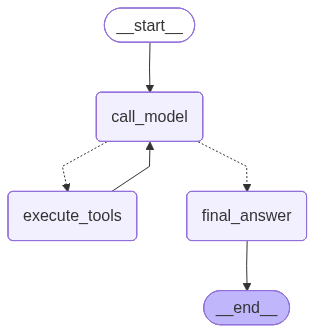

In [14]:
graph_builder = StateGraph(AgentState)

graph_builder.add_node("call_model", call_model_node)
graph_builder.add_node("execute_tools", execute_tools_node)
graph_builder.add_node("final_answer", final_answer_node)

graph_builder.add_edge(START, "call_model")
graph_builder.add_conditional_edges(
    "call_model",
    should_continue,
    {
        "execute_tools": "execute_tools",
        "final_answer": "final_answer",
    },
)
graph_builder.add_edge("execute_tools", "call_model")
graph_builder.add_edge("final_answer", END)

graph = graph_builder.compile()

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    display(Markdown("```mermaid\n" + graph.get_graph().draw_mermaid() + "\n```"))

## 15. Ejecucion real del grafo

Ejecutamos la consulta combinada usando Wikipedia e inventario.


In [ ]:
initial_state = {
    "messages": [system_message, user_message],
    "final_answer": None,
}

graph_result = graph.invoke(initial_state)
display(graph_result["final_answer"])

## 16. LangSmith: que mirar

LangSmith no cambia el codigo del agente: registra la ejecucion para auditar tool calls, argumentos, respuestas, latencia y salida final.


In [ ]:
display({
    "project": os.getenv("LANGCHAIN_PROJECT"),
    "tracing_activo": os.getenv("LANGCHAIN_TRACING_V2") == "true",
    "que_mirar": [
        "tool calls",
        "argumentos enviados a cada tool",
        "respuesta de cada tool",
        "latencia por paso",
        "respuesta final",
    ],
})


## 17. Smoke test contra datos reales

Hacemos una validacion basica contra la fuente de verdad: el CSV de inventario. No es una metrica formal; sirve para detectar rapido si la respuesta incluye precio y stock esperados.


In [ ]:
test_cases = [
    {"question": "Explica que es un monitor LED y decime stock y precio del monitor.", "product": "monitor"},
    {"question": "Explica que es un teclado y decime stock y precio del teclado.", "product": "teclado"},
]


def contains_number(text: str, number: int | float) -> bool:
    value = str(int(number)) if float(number).is_integer() else str(number)
    return re.search(rf"(?<!\d){re.escape(value)}(?!\d)", text) is not None


evaluation_rows = []

for case in test_cases:
    expected = consultar_inventario.invoke({"producto": case["product"]})
    result = graph.invoke({
        "messages": [system_message, HumanMessage(content=case["question"])],
        "final_answer": None,
    })

    answer = result["final_answer"]

    evaluation_rows.append({
        "pregunta": case["question"],
        "producto": case["product"],
        "precio_real": expected.get("precio"),
        "stock_real": expected.get("stock"),
        "respuesta_agente": answer,
        "contiene_precio": expected["encontrado"] and contains_number(answer, expected["precio"]),
        "contiene_stock": expected["encontrado"] and contains_number(answer, expected["stock"]),
    })

pd.DataFrame(evaluation_rows)
